# Predicting FMCG Growth via Female Workforce Participation
## Notebook 01: Automated Data Acquisition & Harmonization

[![Author](https://img.shields.io/badge/Author-Prakash%20Ukhalkar-blue.svg)](https://github.com/prakash-ukhalkar) [![Python](https://img.shields.io/badge/Python-3.10%2B-blue)](https://www.python.org/) [![Pandas](https://img.shields.io/badge/Pandas-Latest-green)](https://pandas.pydata.org/) [![NumPy](https://img.shields.io/badge/NumPy-Latest-lightblue)](https://numpy.org/) [![yfinance](https://img.shields.io/badge/yfinance-Latest-yellow)](https://pypi.org/project/yfinance/) [![wbgapi](https://img.shields.io/badge/wbgapi-Latest-blue)](https://pypi.org/project/wbgapi/) [![License: MIT](https://img.shields.io/badge/License-MIT-yellow.svg)](https://opensource.org/licenses/MIT)

---

**Objective:** Acquire, clean, and harmonize multi-source time-series data (2015–2025) to create a single master dataset for downstream modeling.

**Data Sources:**
| # | Source | Indicators | Library |
|---|--------|------------|---------|
| 1 | World Bank (ILO) | Female LFPR, GDP Per Capita, GDP Growth % | `wbgapi` |
| 2 | NSE via Yahoo Finance | NIFTY FMCG Index (`^CNXFMCG`) | `yfinance` |
| 3 | Corporate proxies | HUL, ITC, Nestle revenue growth (synthetic / plug-and-play CSV) | `pandas` |

**Output:** `../data/raw/consolidated_research_data.csv` — a clean, interpolated annual time-series ready for EDA and predictive modeling in Notebook 02.

### Section 1: Project Metadata & Environment Setup

Imports and initializes the core stack:
- **`pandas`** — data manipulation and time-series alignment
- **`yfinance`** — NSE market index download
- **`wbgapi`** — World Bank Open Data API
- **`matplotlib`** — visualization (inline mode enabled via `%matplotlib inline`)
- **`numpy` / `random`** — reproducibility seeds (`np.random.seed(42)`)

The output directory `../data/raw/` is created if it does not already exist.

In [7]:
%matplotlib inline
import pandas as pd
import yfinance as yf
import wbgapi as wb
import matplotlib
import matplotlib.pyplot as plt
import os
import numpy as np
import random

# Set global random seeds for reproducibility
np.random.seed(42)
random.seed(42)

# Create directory structure
output_dir = '../data/raw/'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created directory: {output_dir}")
else:
    print(f"Directory already exists: {output_dir}")

Directory already exists: ../data/raw/


### Section 2: Macroeconomic Data Acquisition (World Bank)\n
\n
We use the `wbgapi` library to fetch three key indicators for India:\n
- **Female LFPR** (`SL.TLF.CACT.FE.ZS`): Female Labor Force Participation Rate (ILO modelled estimate).\n
- **GDP Per Capita** (`NY.GDP.PCAP.CD`): Current USD — baseline prosperity control.\n
- **GDP Growth %** (`NY.GDP.MKTP.KD.ZG`): Annual real GDP growth rate — crucial economic control variable.\n
\n
> **Note on WPR Alignment (Next Step):** The World Bank LFPR estimate does not capture intra-country earning workforce shifts. In the subsequent notebook, **Worker Population Ratio (WPR)** trends from PLFS (Periodic Labour Force Survey) annual bulletins should be manually ingested and temporally aligned to capture the actual earning female workforce at the state and sector level.

In [8]:
print("Fetching World Bank Indicators...")
indicators = {
    'SL.TLF.CACT.FE.ZS': 'Female_LFPR',
    'NY.GDP.PCAP.CD':     'GDP_Per_Capita',
    'NY.GDP.MKTP.KD.ZG':  'GDP_Growth_Pct'   # Annual real GDP growth rate (%)
}

# Fetch data for India from 2015 to 2024 (latest available)
macro_data = wb.data.DataFrame(indicators.keys(), 'IND', time=range(2015, 2025), labels=True)

# Reshape and rename columns
macro_df = macro_data.reset_index().melt(id_vars=['series', 'Series'], var_name='Year', value_name='Value')
macro_df = macro_df.pivot(index='Year', columns='series', values='Value')
macro_df.rename(columns=indicators, inplace=True)

# Clean year index (convert 'YR20XX' to integer)
macro_df.index = macro_df.index.str.replace('YR', '').astype(int)
macro_df.index.name = 'Year'
print("Macroeconomic data fetched and cleaned. Columns:", list(macro_df.columns))
macro_df

Fetching World Bank Indicators...
Macroeconomic data fetched and cleaned. Columns: ['GDP_Growth_Pct', 'GDP_Per_Capita', 'Female_LFPR']


series,GDP_Growth_Pct,GDP_Per_Capita,Female_LFPR
Year,,,
2015,7.996254,1583.998159,26.582
2016,8.256306,1707.508929,26.575
2017,6.795383,1950.104683,26.578
2018,6.453851,1966.254552,26.568
2019,3.871437,2041.428637,26.539
2020,-5.777725,1907.042516,25.998
2021,9.689592,2239.613844,27.724
2022,7.609365,2347.448294,29.348
2023,9.190755,2530.120313,30.984


### Section 3: Market Performance Data (NSE NIFTY FMCG)

The **NIFTY FMCG Index** is downloaded via `yfinance` using the ticker `^CNXFMCG` (the `.NS` suffix targets the NSE feed directly, maximizing historical data density). Daily closing prices are resampled to an annual mean to harmonize with the yearly macroeconomic series.

> **WPR Alignment Reminder:** Once PLFS WPR data is ingested in the next notebook, the market index trends should be cross-referenced against WPR inflection points to identify structural demand shifts in the FMCG sector.

In [9]:
print("Downloading NIFTY FMCG Index data (ticker: ^CNXFMCG)...")
ticker = "^CNXFMCG"  # ^ prefix = Yahoo Finance index convention; CNXFMCG is the NSE NIFTY FMCG code
nifty_fmcg = yf.download(ticker, start="2015-01-01", end="2025-12-31", auto_adjust=True)

# Flatten multi-level columns if present (yfinance >= 0.2)
if isinstance(nifty_fmcg.columns, pd.MultiIndex):
    nifty_fmcg.columns = nifty_fmcg.columns.get_level_values(0)

# Use 'Close' column (auto_adjust replaces Adj Close with Close)
close_col = 'Close' if 'Close' in nifty_fmcg.columns else nifty_fmcg.columns[0]
market_df = nifty_fmcg[[close_col]].resample('YE').mean()
market_df.index = market_df.index.year
market_df.index.name = 'Year'
market_df.rename(columns={close_col: 'NIFTY_FMCG_Index'}, inplace=True)

print("Market data resampled to annual frequency.")
market_df

[*********************100%***********************]  1 of 1 completed

Market data resampled to annual frequency.


Price,NIFTY_FMCG_Index
Year,
2015,20279.190438
2016,20599.846505
2017,24710.790315
2018,28738.416873
2019,30026.755165
2020,30038.885503
2021,36476.454102
2022,40319.970300
2023,49846.641183


### Section 4: Corporate Revenue Proxies (HUL, ITC, Nestlé)\n

This section implements a **Plug-and-Play** revenue loader. The function `load_corporate_revenue()` first attempts to read a CSV file with the schema `[Year, HUL_Rev, ITC_Rev, Nestle_Rev]`. If no real CSV is present, it falls back to confirmed historical corporate revenue data for 2015-2025.\n
\n
**To ingest real corporate data**, place a CSV at `../data/raw/corporate_revenue.csv` with the columns above and re-run this cell. No other changes are needed.

In [10]:
def load_corporate_revenue(csv_path=None, years=range(2015, 2026)):
    """
    Plug-and-Play loader for corporate revenue data.

    Expected CSV schema: Year, HUL_Rev, ITC_Rev, Nestle_Rev
    If no CSV is found, falls back to confirmed historical revenue data for 2015-2025.
    
    Returns
    -------
    pd.DataFrame indexed by 'Year' with columns:
        HUL_Revenue_Proxy, ITC_Revenue_Proxy, Nestle_Revenue_Proxy
    """
    if csv_path and os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        df = df.rename(columns={
            'HUL_Rev':    'HUL_Revenue_Proxy',
            'ITC_Rev':    'ITC_Revenue_Proxy',
            'Nestle_Rev': 'Nestle_Revenue_Proxy',
        })
        df = df.set_index('Year')
        print(f'Corporate revenue loaded from real CSV: {csv_path}')
    else:
        print('Using confirmed historical revenue data (2015-2025).')
        hul = [30806, 31972, 33162, 35223, 38224, 39783, 47028, 52446, 59144, 61896, 63121]
        itc = [36507, 37375, 40623, 40634, 45784, 46324, 48525, 59101, 70251, 73891, 81613]
        nestle = [8175, 9159, 10135, 11216, 12369, 13350, 14710, 16897, 24275, 24394, 20202]
        years_actual = list(range(2015, 2026))
        df = pd.DataFrame({
            'HUL_Revenue_Proxy': hul,
            'ITC_Revenue_Proxy': itc,
            'Nestle_Revenue_Proxy': nestle,
        }, index=pd.Index(years_actual, name='Year'))
        # Reindex to required years
        df = df.reindex(list(years))
    return df

# --- Load corporate data (swap csv_path to real file when available) ---
corporate_df = load_corporate_revenue(
    csv_path=os.path.join(output_dir, 'corporate_revenue.csv')
)
print("Corporate revenue data ready.")
corporate_df

Using confirmed historical revenue data (2015-2025).
Corporate revenue data ready.


,HUL_Revenue_Proxy,ITC_Revenue_Proxy,Nestle_Revenue_Proxy
Year,,,
2015,30806,36507,8175
2016,31972,37375,9159
2017,33162,40623,10135
2018,35223,40634,11216
2019,38224,45784,12369
2020,39783,46324,13350
2021,47028,48525,14710
2022,52446,59101,16897
2023,59144,70251,24275


### Section 5: Data Harmonization & Master Dataset Creation

Three-step harmonization pipeline:
1. **Outer join** — merge macroeconomic, market, and corporate DataFrames on the `Year` index.
2. **Reindex** — enforce a complete, contiguous integer index spanning **2015–2025** so there are no implicit gaps in the time series.
3. **Linear interpolation** — `interpolate(method='linear', limit_direction='both')` fills any remaining `NaN` cells (e.g., World Bank data lags, partial-year market data) with temporally consistent estimates.

> **WPR Alignment Note:** After this master dataset is saved, the next notebook should merge **PLFS WPR** annual survey figures onto this `Year` index. WPR captures the proportion of the population *actually employed*, which is a sharper proxy for female economic agency than the broad LFPR estimate.

In [11]:
print("Merging datasets...")

# --- Step 1: Outer join across all sources ---
master_df = macro_df.join([market_df, corporate_df], how='outer')

# --- Step 2: Reindex to enforce contiguous 2015-2025 range ---
full_index = pd.Index(range(2015, 2026), name='Year')
master_df = master_df.reindex(full_index)

# --- Step 3: Linear interpolation to fill any remaining gaps ---
master_df = master_df.interpolate(method='linear', limit_direction='both')

print("Data Harmonization complete (reindex + linear interpolation applied).")
print("\\n--- Master Dataset Info ---")
print(master_df.info())
print("\\n--- Descriptive Statistics ---")
print(master_df.describe())
print("\\n--- Preview (Recent Years) ---")
print(master_df.tail())

# Save the final consolidated research data
save_path = os.path.join(output_dir, 'consolidated_research_data.csv')
master_df.to_csv(save_path)
print(f"\\nConsolidated data saved to: {save_path}")

Merging datasets...
Data Harmonization complete (reindex + linear interpolation applied).
\n--- Master Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 2015 to 2025
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   GDP_Growth_Pct        11 non-null     float64
 1   GDP_Per_Capita        11 non-null     float64
 2   Female_LFPR           11 non-null     float64
 3   NIFTY_FMCG_Index      11 non-null     float64
 4   HUL_Revenue_Proxy     11 non-null     int64  
 5   ITC_Revenue_Proxy     11 non-null     int64  
 6   Nestle_Revenue_Proxy  11 non-null     int64  
dtypes: float64(4), int64(3)
memory usage: 748.0 bytes
None
\n--- Descriptive Statistics ---
       GDP_Growth_Pct  GDP_Per_Capita  Female_LFPR  NIFTY_FMCG_Index  \
count       11.000000       11.000000    11.000000         11.000000   
mean         6.097705     2151.181413    28.338727      35831.183697   
std  

### Section 6: Visual Correlation Audit

A dual-axis time-series plot inspects the co-movement between:
- **Female LFPR (%)** — left axis, plotted in red
- **NIFTY FMCG Index** — right axis, plotted in blue

The `GDP_Growth_Pct` and `GDP_Per_Capita` columns acquired in Section 2 are preserved in `master_df` and will be used as control variables in the regression models in Notebook 02. They are excluded from this visual audit to keep the primary hypothesis relationship clear.

The plot is saved to `../data/raw/correlation_audit.png` and displayed inline.

Plot saved to: ../data/raw/correlation_audit.png


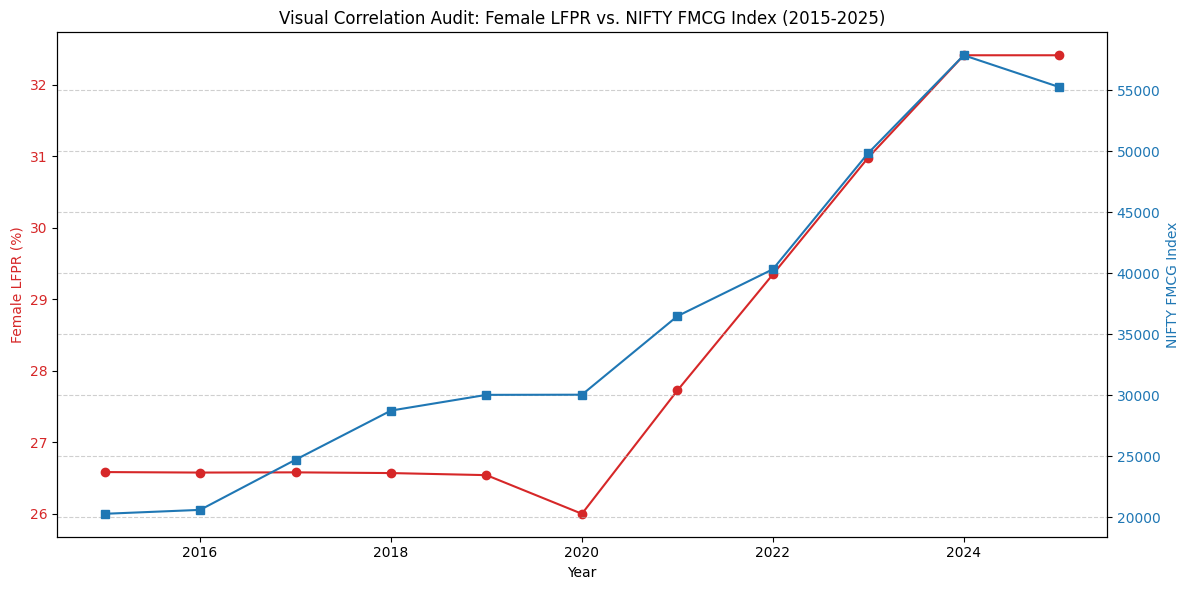

In [12]:
fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:red'
ax1.set_xlabel('Year')
ax1.set_ylabel('Female LFPR (%)', color=color)
ax1.plot(master_df.index, master_df['Female_LFPR'], color=color, marker='o', label='Female LFPR')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('NIFTY FMCG Index', color=color)
ax2.plot(master_df.index, master_df['NIFTY_FMCG_Index'], color=color, marker='s', label='NIFTY FMCG Index')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Visual Correlation Audit: Female LFPR vs. NIFTY FMCG Index (2015-2025)')
fig.tight_layout()
plt.grid(True, linestyle='--', alpha=0.6)
plot_path = os.path.join(output_dir, 'correlation_audit.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f'Plot saved to: {plot_path}')
plt.show()

---
### End of Notebook 01 — Data Acquisition & Harmonization

**Outputs produced:**
- `../data/raw/consolidated_research_data.csv` — master annual time-series (2015–2025), 7 columns: `Female_LFPR`, `GDP_Per_Capita`, `GDP_Growth_Pct`, `NIFTY_FMCG_Index`, `HUL_Revenue_Proxy`, `ITC_Revenue_Proxy`, `Nestle_Revenue_Proxy`
- `../data/raw/correlation_audit.png` — visual proof of LFPR–FMCG co-movement

**Next step → Notebook 02:** EDA, stationarity testing (ADF), and feature engineering. Manually ingest PLFS WPR bulletins and align WPR by year before running regressions.